In [3]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict

In [4]:
load_dotenv()

True

In [5]:
class JokeState(TypedDict):
    topic: str
    joke: str
    explain: str

In [6]:
llm = ChatGroq(model="llama-3.3-70b-versatile")

In [7]:
def generate_joke(state: JokeState) -> JokeState:
    prompt = f"Generate a joke that is suitable for all audiences: {state['topic']}"
    
    joke = llm.invoke(prompt).content
    return {'joke': joke} 

In [8]:
def explain_joke(state: JokeState) -> JokeState:
    prompt = f"Explain the following joke in a way that a child could understand: {state['joke']}"
    
    explain = llm.invoke(prompt)
    return {'explain': explain}

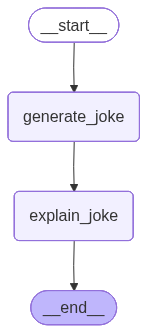

In [9]:
graph = StateGraph(JokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('explain_joke', explain_joke)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'explain_joke')
graph.add_edge('explain_joke', END)


checkpointer = InMemorySaver()
workflow = graph.compile(checkpointer=checkpointer)
workflow

In [15]:
config = {'configurable': {'thread_id': "1"}}

result = workflow.invoke({'topic': 'pizza'}, config=config)
print(result)

{'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty!', 'explain': AIMessage(content='So, you know how we can feel happy or sad sometimes? Like when you\'re playing with your favorite toy, you feel happy, but when you fall down and scrape your knee, you feel sad?\n\nWell, this joke is saying that the pizza is feeling sad, or in a "bad mood." But why? It\'s because it\'s feeling "crusty." Now, pizzas have a crust, which is the hard part around the outside. It\'s like a special edge that holds all the yummy cheese and sauce inside.\n\nSo, when the joke says the pizza is feeling "crusty," it\'s not just talking about the pizza\'s crust. It\'s making a funny connection between the crust on the pizza and the way people can feel when they\'re grumpy or irritable. Sometimes, when people are feeling grumpy, we might say they\'re being "crusty" or "short-tempered." It means they\'re not very nice to be around, and they might even snap at you.\n\

In [16]:
workflow.get_state(config)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty!', 'explain': AIMessage(content='So, you know how we can feel happy or sad sometimes? Like when you\'re playing with your favorite toy, you feel happy, but when you fall down and scrape your knee, you feel sad?\n\nWell, this joke is saying that the pizza is feeling sad, or in a "bad mood." But why? It\'s because it\'s feeling "crusty." Now, pizzas have a crust, which is the hard part around the outside. It\'s like a special edge that holds all the yummy cheese and sauce inside.\n\nSo, when the joke says the pizza is feeling "crusty," it\'s not just talking about the pizza\'s crust. It\'s making a funny connection between the crust on the pizza and the way people can feel when they\'re grumpy or irritable. Sometimes, when people are feeling grumpy, we might say they\'re being "crusty" or "short-tempered." It means they\'re not very nice to be around, and they might

In [17]:
list(workflow.get_state_history(config))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty!', 'explain': AIMessage(content='So, you know how we can feel happy or sad sometimes? Like when you\'re playing with your favorite toy, you feel happy, but when you fall down and scrape your knee, you feel sad?\n\nWell, this joke is saying that the pizza is feeling sad, or in a "bad mood." But why? It\'s because it\'s feeling "crusty." Now, pizzas have a crust, which is the hard part around the outside. It\'s like a special edge that holds all the yummy cheese and sauce inside.\n\nSo, when the joke says the pizza is feeling "crusty," it\'s not just talking about the pizza\'s crust. It\'s making a funny connection between the crust on the pizza and the way people can feel when they\'re grumpy or irritable. Sometimes, when people are feeling grumpy, we might say they\'re being "crusty" or "short-tempered." It means they\'re not very nice to be around, and they migh

In [ ]:
#TIME TRAVEL

workflow.get_state({"configurable":{'thread_id':"1",'checkpoint_id':'1f11dda7-6131-6c9a-8000-6e03a9d19e6c'}})

StateSnapshot(values={'topic': 'technology'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f11dda7-6131-6c9a-8000-6e03a9d19e6c'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-03-12T06:12:34.623605+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f11dda7-612c-6ea5-bfff-25ea2a7d5084'}}, tasks=(PregelTask(id='7feedbcb-6454-359e-c458-ad7277455bda', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result={'joke': 'Why did the computer go to the doctor?\n\nBecause it had a virus! (get it?)'}),), interrupts=())

In [20]:
workflow.invoke(None,{'configurable':{'thread_id':"1","checkpoint_id":'1f11dda7-6131-6c9a-8000-6e03a9d19e6c'}})

{'topic': 'technology',
 'joke': 'Why did the computer go to the doctor?\n\nIt had a virus! (get it?)',
 'explain': AIMessage(content='Oh boy, that\'s a funny joke. So, you know how sometimes you can get sick and have to go to the doctor? Like when you have a cold or a tummy ache?\n\nWell, computers can get "sick" too, but not in the same way that people do. When a computer gets a "virus", it\'s not like the kind of virus that makes you feel yucky. It\'s actually a kind of bad code that can make the computer not work properly.\n\nSo, in this joke, the computer went to the doctor because it had a "virus", which is a play on words. It\'s like the joke is saying, "Oh no, the computer is sick! It must have a virus, just like people do when they\'re sick!" But really, it\'s just a computer problem that needs to be fixed.\n\nIt\'s like a little pun, and puns are like jokes that use words in a funny way. Does that make sense?', additional_kwargs={}, response_metadata={'token_usage': {'complet

In [21]:
list(workflow.get_state_history(config))

[StateSnapshot(values={'topic': 'technology', 'joke': 'Why did the computer go to the doctor?\n\nIt had a virus! (get it?)', 'explain': AIMessage(content='Oh boy, that\'s a funny joke. So, you know how sometimes you can get sick and have to go to the doctor? Like when you have a cold or a tummy ache?\n\nWell, computers can get "sick" too, but not in the same way that people do. When a computer gets a "virus", it\'s not like the kind of virus that makes you feel yucky. It\'s actually a kind of bad code that can make the computer not work properly.\n\nSo, in this joke, the computer went to the doctor because it had a "virus", which is a play on words. It\'s like the joke is saying, "Oh no, the computer is sick! It must have a virus, just like people do when they\'re sick!" But really, it\'s just a computer problem that needs to be fixed.\n\nIt\'s like a little pun, and puns are like jokes that use words in a funny way. Does that make sense?', additional_kwargs={}, response_metadata={'tok

In [24]:
workflow.update_state({'configurable':{'thread_id':"1",'checkpoint_id':'1f11dda7-6131-6c9a-8000-6e03a9d19e6c','checkpoint_ns':""}},{'topic':'pizza'})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f11de05-c316-631c-8001-b6e9298aab01'}}

In [25]:
list(workflow.get_state_history(config))

[StateSnapshot(values={'topic': 'pizza'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f11de05-c316-631c-8001-b6e9298aab01'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-03-12T06:54:48.181634+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f11dda7-6131-6c9a-8000-6e03a9d19e6c'}}, tasks=(PregelTask(id='1ca992ee-14ed-d2ad-6682-769237036ba1', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'technology', 'joke': 'Why did the computer go to the doctor?\n\nIt had a virus! (get it?)', 'explain': AIMessage(content='Oh boy, that\'s a funny joke. So, you know how sometimes you can get sick and have to go to the doctor? Like when you have a cold or a tummy ache?\n\nWell, computers can get "sick" too, but not in the same way that people do. 

In [28]:
workflow.invoke(None,{'configurable':{'thread_id':"1",'checkpoint_id':'1f11de05-c316-631c-8001-b6e9298aab01'}})

{'topic': 'pizza',
 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty!',
 'explain': AIMessage(content='So, you know how sometimes you might feel grumpy or upset, and we say you\'re in a "bad mood"? Like when you\'re tired or didn\'t get what you wanted?\n\nWell, this joke is saying that the pizza is in a bad mood, but it\'s not because it\'s tired or didn\'t get what it wanted. It\'s because it\'s "feeling a little crusty".\n\nThe word "crusty" has a special meaning here. When we talk about bread, like pizza, the "crust" is the outside part that\'s crunchy and hard. But when we say someone is "feeling crusty", it means they\'re being a little grumpy or irritable, like they have a hard outside.\n\nSo, the joke is making a funny connection between the pizza\'s crust (the outside part of the bread) and the idea of being grumpy or "crusty". It\'s like the pizza is saying, "Hey, I\'m feeling a little grumpy, and it\'s because I\'m a pizza, and I have a cru